# Early Detection of Cardiac Abnormalities using ECG Signals

This notebook presents the classification of ECG heartbeats using Deep Learning models: Convolutional Neural Networks (CNN), Recurrent Neural Networks (RNN), and Gated Recurrent Units (GRU). There are utilizing the **MIT-BIH Arrhythmia Dataset**, a standard benchmark for evaluating heartbeat classification algorithms.

* **Dataset:** MIT-BIH Arrhythmia Dataset
* **Models Evaluated:** CNN, Simple RNN, GRU
* **Objective:** Accurately classify heartbeat signals into 5 distinct categories.

## 1. Library Imports
It begin by importing the necessary libraries and setting a global seaborn theme to ensure all our visualizations look modern and professional.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils import shuffle


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, SimpleRNN, GRU
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

# Set global aesthetic parameters for plots
sns.set_theme(style="whitegrid", palette="muted")

## 2. Data Loading
The dataset is loaded and shuffled to ensure the models do not learn any artificial ordering from the raw files.

In [3]:
train = pd.read_csv("mitbih_train.csv", header=None)
test = pd.read_csv("mitbih_test.csv", header=None)

# Shuffle the data
train = shuffle(train, random_state=42)
test = shuffle(test, random_state=42)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


## 3. Data Exploration
Let's inspect the structure of our data. The first 187 columns represent the time-steps of the ECG signal, and the 188th column is our target class.

In [4]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
10563,0.965812,0.792023,0.116809,0.000000,0.162393,0.213675,0.264957,0.247863,0.270655,0.259259,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25843,1.000000,0.597015,0.000000,0.109453,0.094527,0.084577,0.074627,0.094527,0.114428,0.124378,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15891,0.831382,0.714286,0.491803,0.206089,0.086651,0.042155,0.032787,0.025761,0.046838,0.032787,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62606,1.000000,0.837705,0.236066,0.037705,0.252459,0.329508,0.319672,0.306557,0.304918,0.306557,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84283,0.868590,0.448718,0.490385,0.477564,0.461538,0.455128,0.416667,0.304487,0.182692,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0


In [5]:
print("--- Dataset Info ---")
train.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 87554 entries, 10563 to 15795
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 126.2 MB


In [6]:
print("\n--- Class Distribution ---")
print(train[187].value_counts())


--- Class Distribution ---
187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


**Crucial Observation:** The dataset is highly imbalanced. Class 0 (Normal) heavily dominates the dataset. Relying solely on "Accuracy" as a metric will be misleading. It must also look at the confusion matrix and classification reports.

## 4. Data Visualizations
Visualizing the data helps understand what the models will be learning. Let's look at the class distribution and sample waveforms.

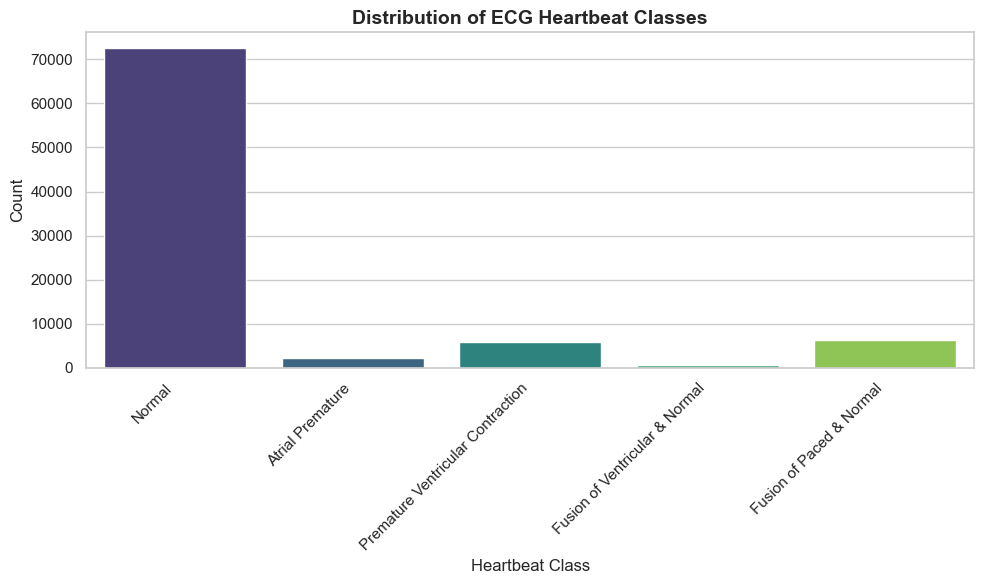

In [7]:
labels = {
    0: "Normal",
    1: "Atrial Premature",
    2: "Premature Ventricular Contraction",
    3: "Fusion of Ventricular & Normal",
    4: "Fusion of Paced & Normal"
}

# 1. Plot Class Distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=train[187], palette="viridis")
plt.title("Distribution of ECG Heartbeat Classes", fontsize=14, fontweight='bold')
plt.xlabel("Heartbeat Class", fontsize=12)
plt.ylabel("Count", fontsize=12)
ax.set_xticklabels(labels.values(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

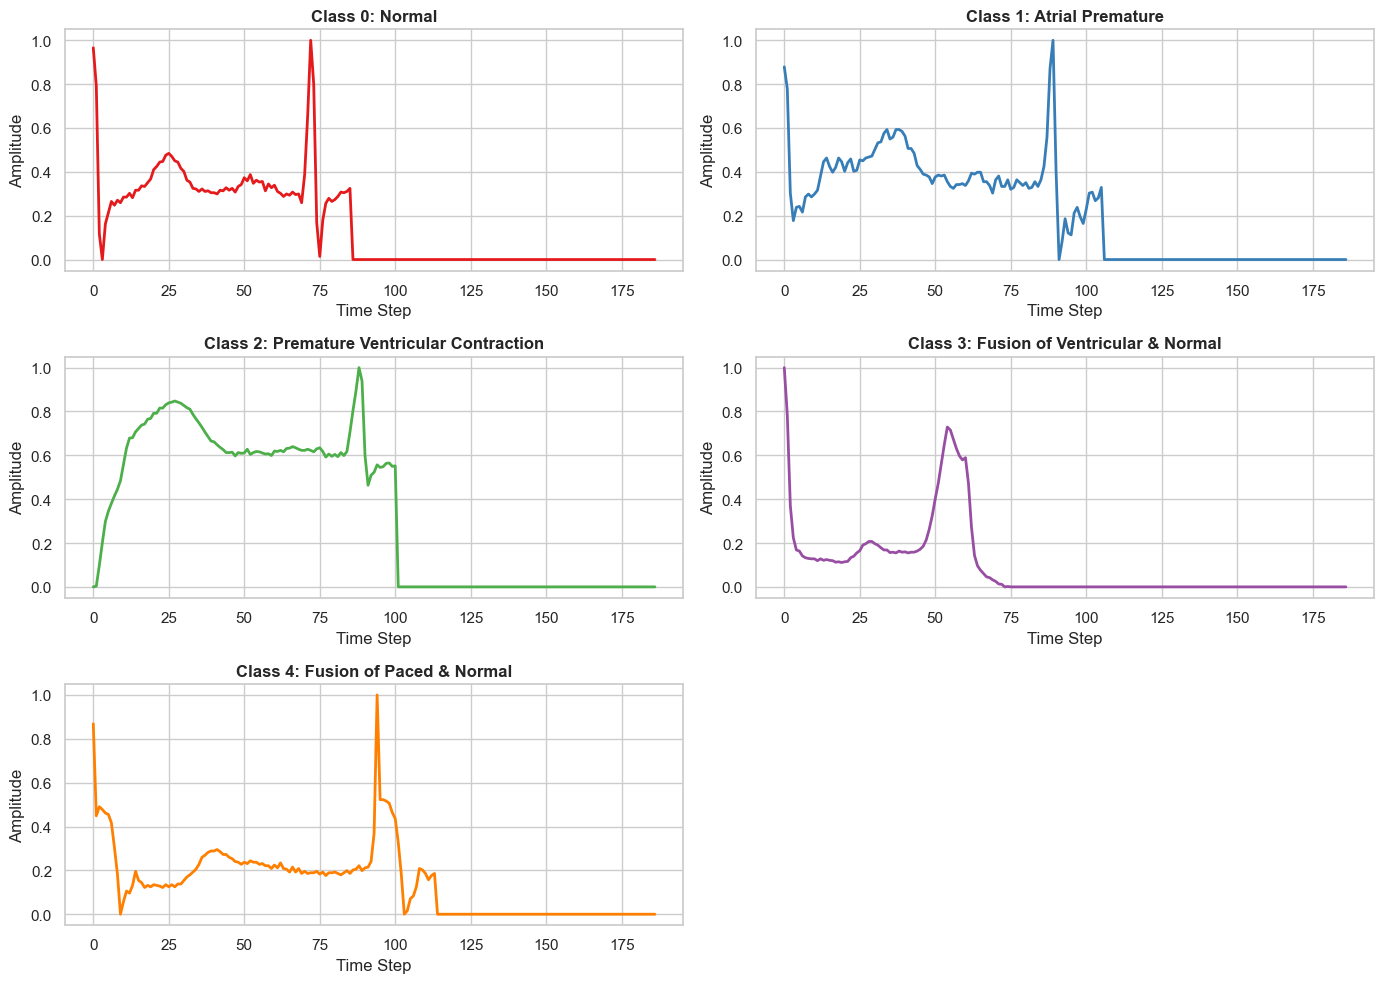

In [8]:
# 2. Plot Sample ECG Signals per Class
plt.figure(figsize=(14, 10))
for i in range(5):
    sample = train[train[187] == i].iloc[0, :187]
    plt.subplot(3, 2, i+1)
    plt.plot(sample, color=sns.color_palette("Set1")[i], linewidth=2)
    plt.title(f"Class {i}: {labels[i]}", fontsize=12, fontweight='bold')
    plt.xlabel("Time Step")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

## 5. Data Preprocessing
It isolate the features (`X`) from the target (`y`), scale the signals so they have a mean of 0 and a variance of 1, and reshape them for sequence modeling.

In [9]:
X_train = train.iloc[:, :187].values
y_train = train.iloc[:, 187].values

X_test = test.iloc[:, :187].values
y_test = test.iloc[:, 187].values

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Reshape for Deep Learning models (Samples, Time Steps, Features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# One-hot encode the target variables
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(f"X_train shape: {X_train.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")

X_train shape: (87554, 187, 1)
y_train_cat shape: (87554, 5)


## 6. CNN Model (Convolutional Neural Network)
CNNs are excellent at extracting spatial/local patterns, making them highly effective for identifying specific waveform spikes like the QRS complex in an ECG.

In [11]:
cnn = Sequential([
    Conv1D(64, 3, activation="relu", input_shape=(187, 1)),
    MaxPooling1D(2),
    Conv1D(128, 3, activation="relu"),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(5, activation="softmax")
])

cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 185, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 92, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 90, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       737,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 763,013 (2.91 MB)

 Trainable params: 763,013 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train the model
cnn_history = cnn.fit(X_train, y_train_cat, epochs=15, batch_size=64, validation_split=0.2, verbose=1)

Epoch 1/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9457 - loss: 0.2019 - val_accuracy: 0.9676 - val_loss: 0.1154
Epoch 2/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9681 - loss: 0.1177 - val_accuracy: 0.9749 - val_loss: 0.0925
Epoch 3/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9733 - loss: 0.0944 - val_accuracy: 0.9776 - val_loss: 0.0814
Epoch 4/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9766 - loss: 0.0817 - val_accuracy: 0.9797 - val_loss: 0.0737
Epoch 5/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9794 - loss: 0.0703 - val_accuracy: 0.9802 - val_loss: 0.0702
Epoch 6/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9813 - loss: 0.0642 - val_accuracy: 0.9818 - val_loss: 0.0675
Epoch 7/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9830 - loss: 0.0576 - val_accuracy: 0.9829 - val_loss: 0.0652
Epoch 8/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9837 - loss: 0.

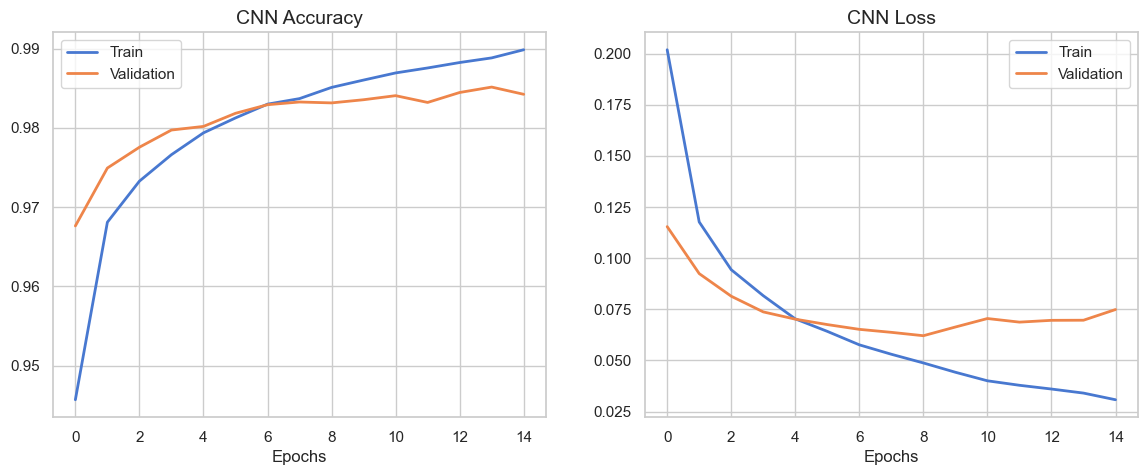

In [13]:
# Accuracy and Loss Subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title("CNN Accuracy", fontsize=14)
axes[0].set_xlabel("Epochs")
axes[0].legend()

axes[1].plot(cnn_history.history['loss'], label='Train', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title("CNN Loss", fontsize=14)
axes[1].set_xlabel("Epochs")
axes[1].legend()

plt.show()

In [14]:
# Predictions and Metrics
cnn_pred = np.argmax(cnn.predict(X_test), axis=1)
print(f"\nCNN Accuracy: {accuracy_score(y_test, cnn_pred):.4f}\n")
print("CNN Classification Report:\n", classification_report(y_test, cnn_pred, target_names=labels.values()))

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

CNN Accuracy: 0.9829

CNN Classification Report:
                                    precision    recall  f1-score   support

                           Normal       0.99      1.00      0.99     18118
                 Atrial Premature       0.90      0.74      0.81       556
Premature Ventricular Contraction       0.96      0.94      0.95      1448
   Fusion of Ventricular & Normal       0.91      0.72      0.80       162
         Fusion of Paced & Normal       1.00      0.98      0.99      1608

                         accuracy                           0.98     21892
                        macro avg       0.95      0.87      0.91     21892
                     weighted avg       0.98      0.98      0.98     21892



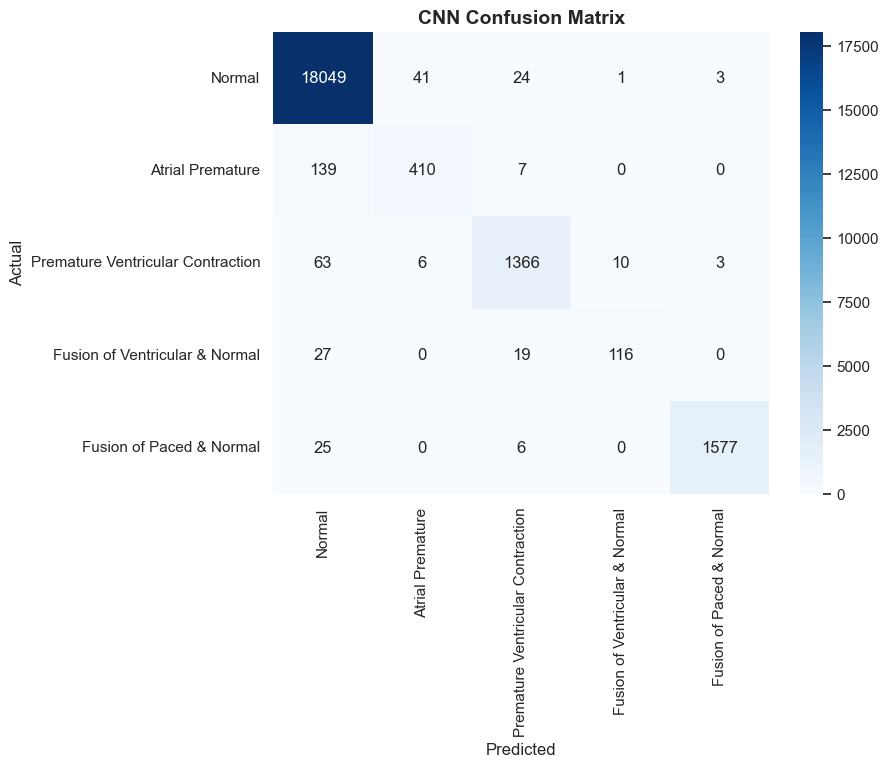

In [15]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, cnn_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels.values(), yticklabels=labels.values())
plt.title("CNN Confusion Matrix", fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 7. RNN Model (Simple Recurrent Neural Network)
Simple RNNs capture sequential data but often struggle with long sequences (like our 187 time-steps) due to the vanishing gradient problem.

In [16]:
rnn = Sequential([
    SimpleRNN(128, input_shape=(187, 1)),
    Dropout(0.5),
    Dense(5, activation="softmax")
])

rnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,285 (67.52 KB)

 Trainable params: 17,285 (67.52 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Train the model
rnn_history = rnn.fit(X_train, y_train_cat, epochs=15, batch_size=64, validation_split=0.2, verbose=1)

Epoch 1/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.8264 - loss: 0.6754 - val_accuracy: 0.8255 - val_loss: 0.6548
Epoch 2/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.8284 - loss: 0.6606 - val_accuracy: 0.8258 - val_loss: 0.6570
Epoch 3/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.8245 - loss: 0.6563 - val_accuracy: 0.8265 - val_loss: 0.6242
Epoch 4/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.8295 - loss: 0.6259 - val_accuracy: 0.8265 - val_loss: 0.6234
Epoch 5/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.8295 - loss: 0.6239 - val_accuracy: 0.8253 - val_loss: 0.6284
Epoch 6/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 32s 29ms/step - accuracy: 0.8294 - loss: 0.6250 - val_accuracy: 0.8260 - val_loss: 0.6245
Epoch 7/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.8282 - loss: 0.6231 - val_accuracy: 0.8272 - val_loss: 0.5769
Epoch 8/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.8287 -

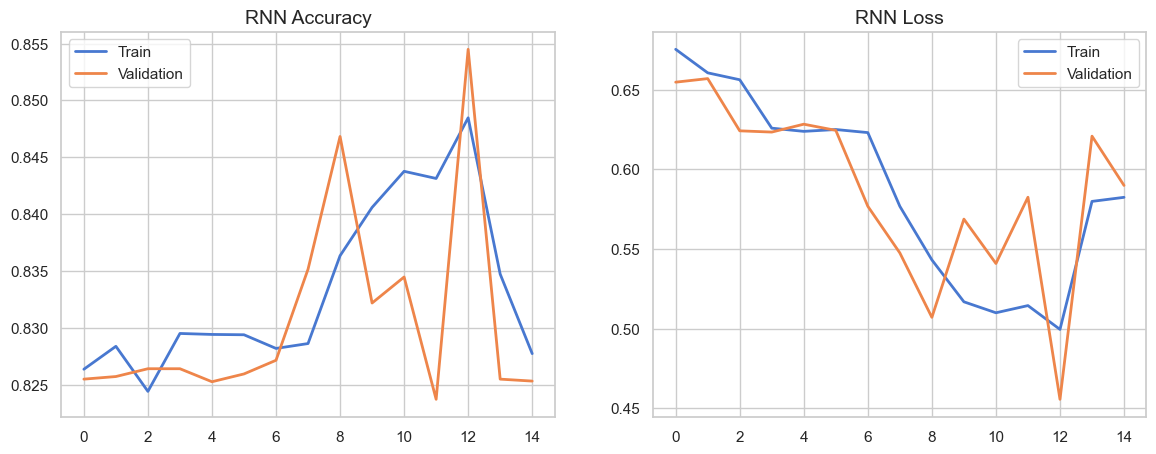

In [18]:
# Accuracy and Loss Subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rnn_history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(rnn_history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title("RNN Accuracy", fontsize=14)
axes[0].legend()

axes[1].plot(rnn_history.history['loss'], label='Train', linewidth=2)
axes[1].plot(rnn_history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title("RNN Loss", fontsize=14)
axes[1].legend()

plt.show()

In [19]:
# Predictions and Metrics
rnn_pred = np.argmax(rnn.predict(X_test), axis=1)
print(f"\nRNN Accuracy: {accuracy_score(y_test, rnn_pred):.4f}\n")
print("RNN Classification Report:\n", classification_report(y_test, rnn_pred, target_names=labels.values()))

685/685 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step

RNN Accuracy: 0.8276

RNN Classification Report:
                                    precision    recall  f1-score   support

                           Normal       0.83      1.00      0.91     18118
                 Atrial Premature       0.00      0.00      0.00       556
Premature Ventricular Contraction       0.00      0.00      0.00      1448
   Fusion of Ventricular & Normal       0.00      0.00      0.00       162
         Fusion of Paced & Normal       0.00      0.00      0.00      1608

                         accuracy                           0.83     21892
                        macro avg       0.17      0.20      0.18     21892
                     weighted avg       0.68      0.83      0.75     21892



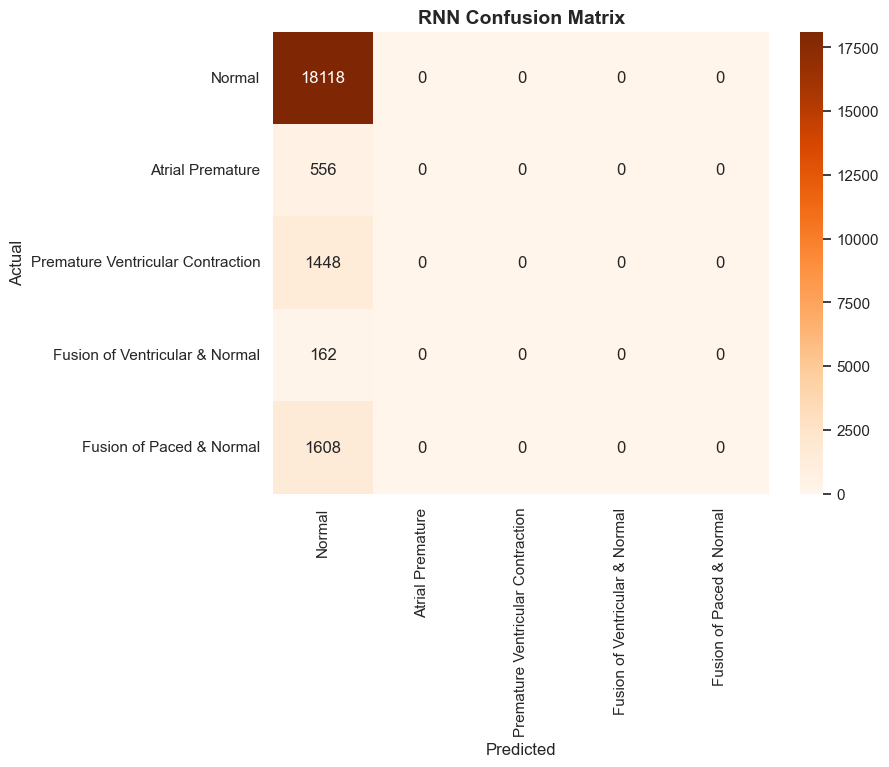

In [20]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rnn_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=labels.values(), yticklabels=labels.values())
plt.title("RNN Confusion Matrix", fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 8. GRU Model (Gated Recurrent Unit)
GRUs are an advanced form of RNN. They use update and reset gates to solve the vanishing gradient problem, allowing them to retain information over longer time-steps much better than a Simple RNN.

In [21]:
gru = Sequential([
    GRU(128, input_shape=(187, 1)),
    Dropout(0.5),
    Dense(5, activation="softmax")
])

gru.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,949 (199.02 KB)

 Trainable params: 50,949 (199.02 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train the model
gru_history = gru.fit(X_train, y_train_cat, epochs=15, batch_size=64, validation_split=0.2, verbose=1)

Epoch 1/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 97s 87ms/step - accuracy: 0.8270 - loss: 0.6658 - val_accuracy: 0.8244 - val_loss: 0.5540
Epoch 2/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 100s 91ms/step - accuracy: 0.8819 - loss: 0.4223 - val_accuracy: 0.9101 - val_loss: 0.3353
Epoch 3/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 101s 92ms/step - accuracy: 0.9257 - loss: 0.2842 - val_accuracy: 0.9410 - val_loss: 0.2268
Epoch 4/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 103s 94ms/step - accuracy: 0.9414 - loss: 0.2110 - val_accuracy: 0.9472 - val_loss: 0.1837
Epoch 5/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 101s 92ms/step - accuracy: 0.9495 - loss: 0.1794 - val_accuracy: 0.9544 - val_loss: 0.1605
Epoch 6/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 101s 92ms/step - accuracy: 0.9563 - loss: 0.1543 - val_accuracy: 0.9616 - val_loss: 0.1395
Epoch 7/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 117s 107ms/step - accuracy: 0.9615 - loss: 0.1348 - val_accuracy: 0.9636 - val_loss: 0.1280
Epoch 8/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 136s 124ms/step - accuracy:

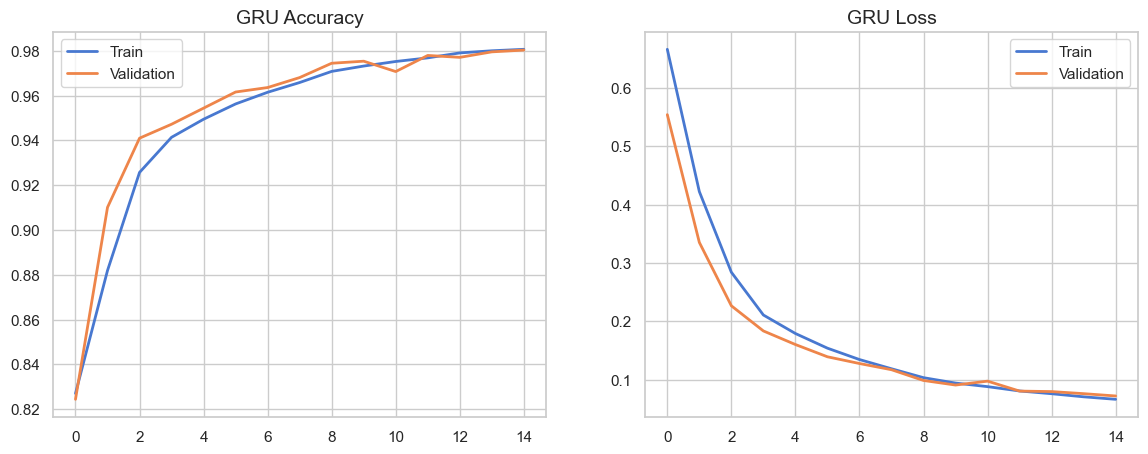

In [23]:
# Accuracy and Loss Subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gru_history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(gru_history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title("GRU Accuracy", fontsize=14)
axes[0].legend()

axes[1].plot(gru_history.history['loss'], label='Train', linewidth=2)
axes[1].plot(gru_history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title("GRU Loss", fontsize=14)
axes[1].legend()

plt.show()

In [24]:
# Predictions and Metrics
gru_pred = np.argmax(gru.predict(X_test), axis=1)
print(f"\nGRU Accuracy: {accuracy_score(y_test, gru_pred):.4f}\n")
print("GRU Classification Report:\n", classification_report(y_test, gru_pred, target_names=labels.values()))

685/685 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step

GRU Accuracy: 0.9783

GRU Classification Report:
                                    precision    recall  f1-score   support

                           Normal       0.98      1.00      0.99     18118
                 Atrial Premature       0.95      0.63      0.76       556
Premature Ventricular Contraction       0.94      0.94      0.94      1448
   Fusion of Ventricular & Normal       0.83      0.70      0.76       162
         Fusion of Paced & Normal       0.99      0.96      0.97      1608

                         accuracy                           0.98     21892
                        macro avg       0.94      0.85      0.88     21892
                     weighted avg       0.98      0.98      0.98     21892



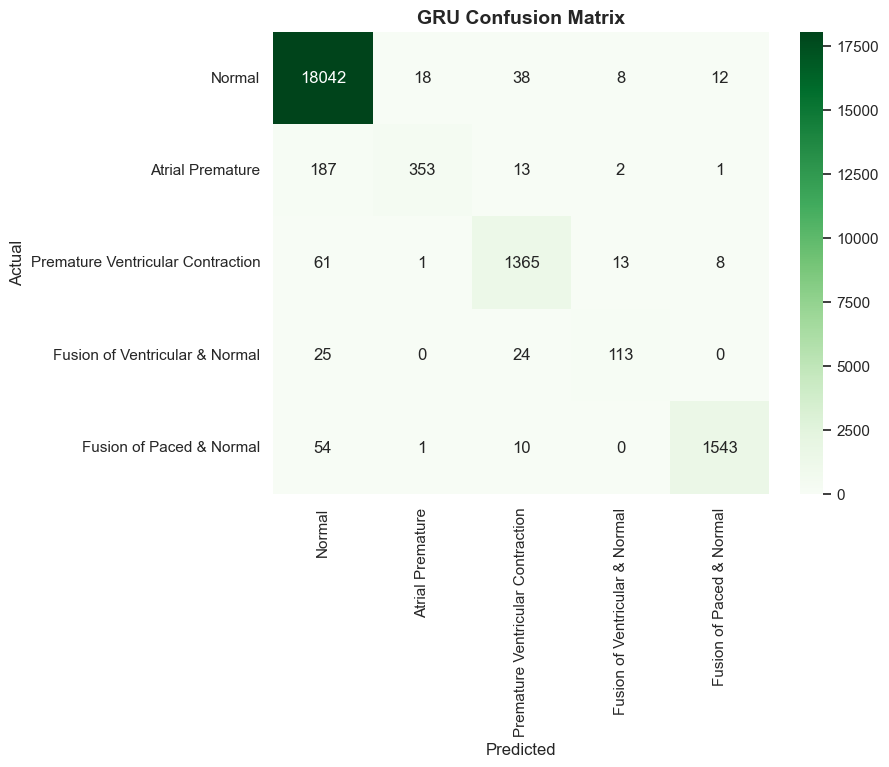

In [25]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, gru_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels.values(), yticklabels=labels.values())
plt.title("GRU Confusion Matrix", fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 9. Model Comparison & Conclusion
This section compares the final performance of the CNN, RNN, and GRU models visually.

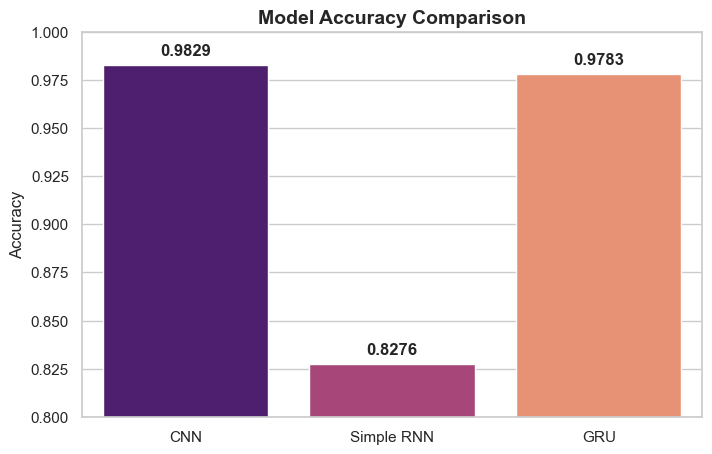

In [26]:
accuracies = [
    accuracy_score(y_test, cnn_pred),
    accuracy_score(y_test, rnn_pred),
    accuracy_score(y_test, gru_pred)
]
model_names = ['CNN', 'Simple RNN', 'GRU']

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=model_names, y=accuracies, palette="magma")
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylim(0.8, 1.0) # Zoom in to see the differences clearly
plt.ylabel("Accuracy")

# Add text labels on top of the bars
for i, v in enumerate(accuracies):
    ax.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold', fontsize=12)

plt.show()